<a href="https://colab.research.google.com/github/MatteoBaraldi/Machine-Learning-for-Bioengineering/blob/giovanni/MOD-2/01_Clustering/exercise_kmeans_hierarchical_solved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice: K-means and Hierarchical Clustering

## Learning objectives

By the end of this practice you will be able to:

- apply K-means and hierarchical clustering
- compare clustering results using visual inspection and quantitative metrics
- discuss when centroid-based and hierarchical approaches are more appropriate

## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

np.random.seed(42)

## 2. Create a synthetic dataset

The dataset below includes four subpopulations that are not well represented by spherical clusters.

In [ ]:
# ---- Cluster 1 (compact) ----
mean1 = [2, 2, 2]
cov1 = [[0.2, 0.05, 0.0],
        [0.05, 0.2, 0.05],
        [0.0, 0.05, 0.2]]
X1 = np.random.multivariate_normal(mean1, cov1, 120)

# ---- Cluster 2 (elongated) ----
mean2 = [6, 5, 7]
cov2 = [[2.0, 1.5, 1.0],
        [1.5, 2.0, 1.2],
        [1.0, 1.2, 1.5]]
X2 = np.random.multivariate_normal(mean2, cov2, 180)

# ---- Cluster 3 (overlapping, high variance) ----
mean3 = [4, 8, 5]
cov3 = [[1.5, -0.8, 0.3],
        [-0.8, 2.0, -0.5],
        [0.3, -0.5, 1.5]]
X3 = np.random.multivariate_normal(mean3, cov3, 150)

# ---- Cluster 4 (curved trajectory) ----
t = np.linspace(0, 1, 160)
x = 3 + 5*t
y = 3 + 4*(t**2)
z = 2 + 3*np.sin(2*np.pi*t)
curve = np.vstack([x, y, z]).T
noise = np.random.normal(scale=0.3, size=curve.shape)
X4 = curve + noise
#4 deliberately different cluster geometry, difficult that a 3D curve manages to correctly represent this shape --> density or connectvity method have advantage
# ---- Combine dataset ----
X = np.vstack([X1, X2, X3, X4])
y_true = np.array(
    [0]*len(X1) +
    [1]*len(X2) +
    [2]*len(X3) +
    [3]*len(X4)
)

feature_names = [
    "Biomarker 1",
    "Biomarker 2",
    "Biomarker 3",
]

df = pd.DataFrame(X, columns=feature_names)
df["true_group"] = y_true
df.head()

,Biomarker 1,Biomarker 2,Biomarker 3,true_group
0,1.943501,1.652579,2.030947,0
1,1.487645,1.499197,1.635737,0
2,1.747449,1.538362,1.262081,0
3,1.628577,1.918802,1.921668,0
4,1.021909,2.349546,2.231973,0


## 3. Quick exploration

Make 2D plots of all the possible projections. The 4 clusters are not perfecly separated by any 2D projections. Choose the projection that better separates the clusters and use that one for the rest of the exercise (but remember that: 1) clustering works with all the features; 2) in a real case you don't know the "true" clusters).

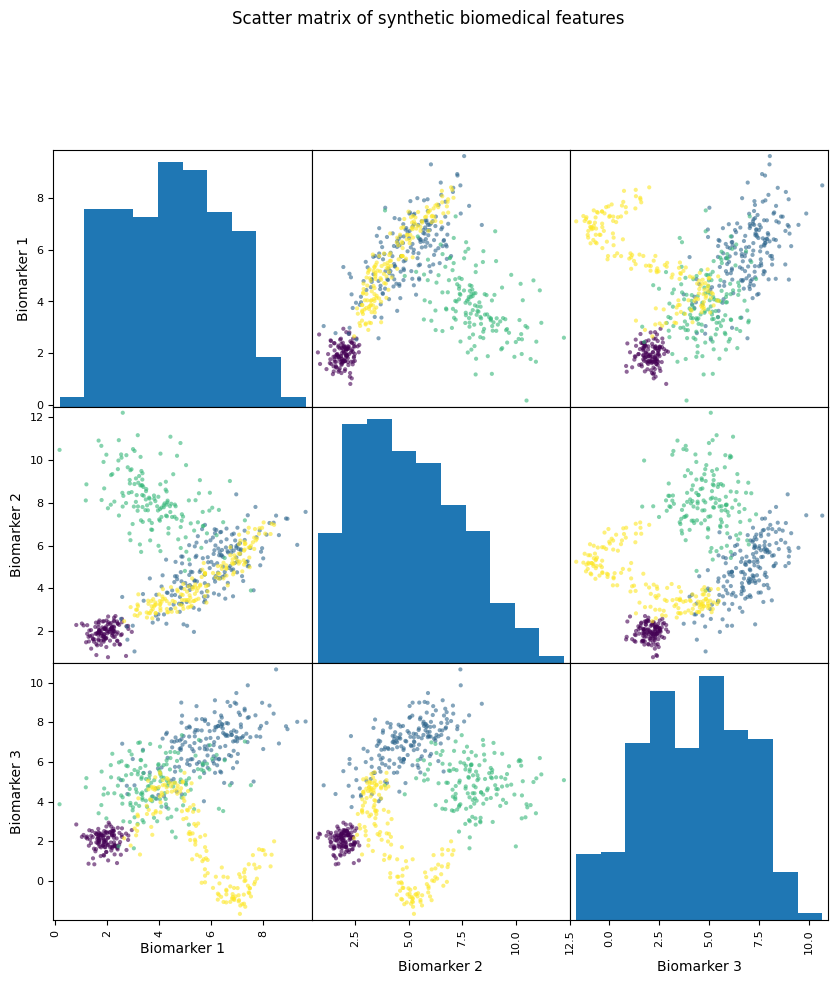

In [ ]:
pd.plotting.scatter_matrix( #confronting three biomarkers with each other
    df[feature_names],
    figsize=(10, 10),
    diagonal="hist",
    alpha=0.6,
    c=y_true
)
plt.suptitle("Scatter matrix of synthetic biomedical features", y=1.02)
plt.show()

## 4. Standardize the features

Normalize the features to zero mean and unitary standard deviation

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_names])

## 6. K-means clustering

Try to define the optimal number of clusters using the elbow method and the silhoutte score.

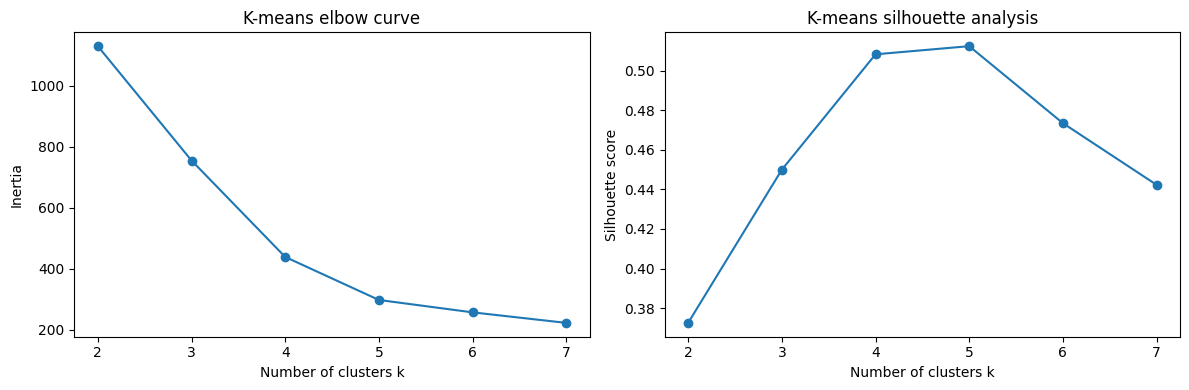

In [ ]:
k_values = range(2, 8)
kmeans_inertia = [] #this monotonically non increasing in k
kmeans_silhouette = [] #genuine self contained maximum: it will not give exact result

for k in k_values:
    model = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = model.fit_predict(X_scaled)
    kmeans_inertia.append(model.inertia_)
    kmeans_silhouette.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(list(k_values), kmeans_inertia, marker="o")
ax[0].set_xlabel("Number of clusters k")
ax[0].set_ylabel("Inertia")
ax[0].set_title("K-means elbow curve")

ax[1].plot(list(k_values), kmeans_silhouette, marker="o")
ax[1].set_xlabel("Number of clusters k")
ax[1].set_ylabel("Silhouette score")
ax[1].set_title("K-means silhouette analysis")

plt.tight_layout()
plt.show()

* Perform clustering with Kmeans using 4 clusters (even if that's probably not what you should do based on the plots before)
* Create a scatter plot in 2D over the features selected before with samples coloured as the Kmeans labels

In [ ]:
kmeans = KMeans(n_clusters=4, n_init=20, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

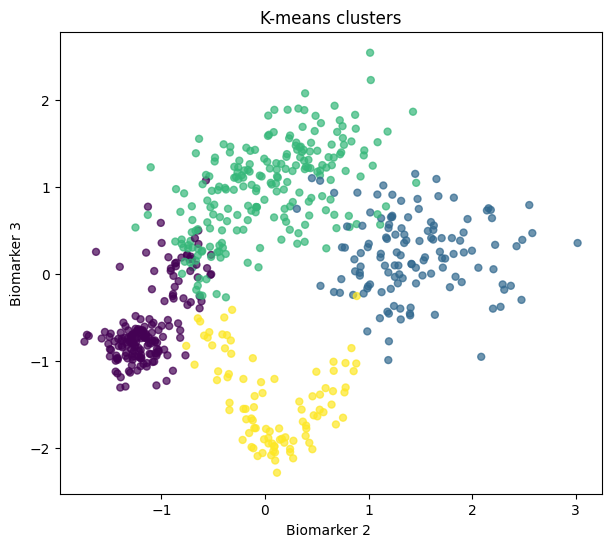

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(X_scaled[:, 1], X_scaled[:, 2], c=kmeans_labels, s=25, alpha=0.7)
plt.xlabel("Biomarker 2 ")
plt.ylabel("Biomarker 3")
plt.title("K-means clusters") #with this I see overlapping btw clusters 2 and 3
plt.show()

## 7. Hierarchical clustering

* Perform hierarchical clustering using the class AgglomerativeClustering
* Test the different linkage methods: ward, complete, average, and single
* For each method compute the silhoutte score

In [ ]:
linkages = ["ward", "complete", "average", "single"]
hier_results = [] #hierarchical better , repeatedly merges two closest clusters until chosen linkage criterion, until only desired number of clusters remain

for linkage_name in linkages: #different type of linkage
    model = AgglomerativeClustering(n_clusters=4, linkage=linkage_name)
    labels = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    hier_results.append((linkage_name, sil))

results_df = pd.DataFrame(
    hier_results,
    columns=["linkage", "silhouette_score", ]
).sort_values(["silhouette_score"], ascending=False)
results_df


,linkage,silhouette_score
2,average,0.499817
0,ward,0.494808
1,complete,0.451270
3,single,0.092378


* Perform clustering using the best linkage method identified

In [ ]:
best_linkage = results_df.iloc[0]["linkage"]
hierarchical = AgglomerativeClustering(n_clusters=4, linkage=best_linkage)
hier_labels = hierarchical.fit_predict(X_scaled)

print(f"Best linkage according to ARI (teaching only): {best_linkage}")
print(f"Hierarchical silhouette score: {silhouette_score(X_scaled, hier_labels):.3f}")

Best linkage according to ARI (teaching only): average
Hierarchical silhouette score: 0.500


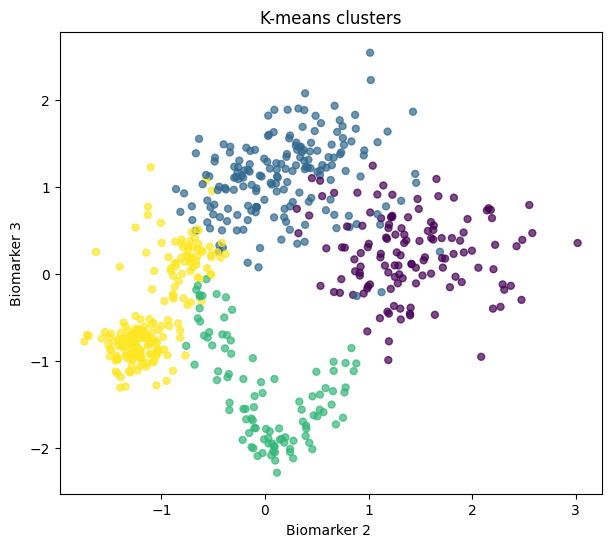

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(X_scaled[:, 1], X_scaled[:, 2], c=hier_labels, s=25, alpha=0.7)
plt.xlabel("Biomarker 2 ")
plt.ylabel("Biomarker 3")
plt.title("K-means clusters")
plt.show()

## 8. Dendrogram

Use the methods linkage and dendrogram to plot the hierarchical tree connecting the samples in the dataset.

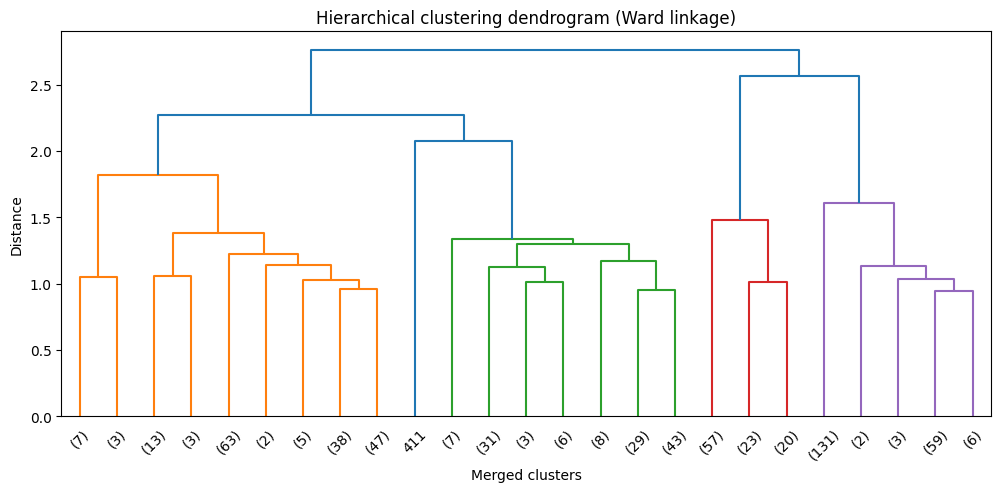

In [ ]:
Z = linkage(X_scaled, method=best_linkage) #dendrogram a tree diagram where y-axis is distance at which two braanches were merged and x-axis lays individual samples

plt.figure(figsize=(12, 5)) #just shown last 25 merges: I can cut horizontally in order to visually pick the number of clusters, without cutting through a merge
dendrogram(Z, truncate_mode="lastp", p=25, leaf_rotation=45, leaf_font_size=10)
plt.title("Hierarchical clustering dendrogram (Ward linkage)")
plt.xlabel("Merged clusters")
plt.ylabel("Distance")
plt.show()

## 9. Compare K-means and hierarchical clustering

* Compare the two methods with respect to silhoutte score and adjusted rank index


In [ ]:
comparison = pd.DataFrame({
    "Method": ["K-means", f"Hierarchical ({best_linkage})"],
    "Silhouette score": [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, hier_labels) #this only looks at gemoetry of found clusters, no access to ground truth so intrinsically biased toward round compact solutions
    ],
    "Adjusted Rand index": [
        adjusted_rand_score(y_true, kmeans_labels),
        adjusted_rand_score(y_true, hier_labels) #compares predicted against true labels, correcting for chance agreement
    ]
})

comparison #second is the metric that tells which method got the rght answer, independently on structure because it is external metric (silhouette internal validity metric, use if checking structure)


,Method,Silhouette score,Adjusted Rand index
0,K-means,0.508369,0.597806
1,Hierarchical (average),0.499817,0.620330
